# Deconvolution Plot for Single Gene

In this notebook, we refactor the deconvolution plots to include both the gene expression and chromatin on a single plot. 

As a trial, we look at DIC1 and CLB2. So that we can plan to script creating plots for every gene in the genome

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Next we will do the same, without needing to deconvolve
# we want to be able to load the deconvolution results from disk and plot

In [3]:
chromatin_directory_path = 'output/deconvolve_chromatin_2023_12_15/'
gene_expression_directory_path = 'output/deconvolve_gene_expression_2024_01_04/'

In [16]:
from src.deconvolution_plotter import load_deconvolution_models_from_disk

gene_name = 'CLB2'

deconv_plotter = load_deconvolution_models_from_disk(gene_name, chromatin_directory_path, 
                                    gene_expression_directory_path)

Loading MNase reads...Done.
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


The histogram shape around the TSS is: (3, 9)


Text(0.5, 1.0, 'CLB2 peak-to-trough ratios')

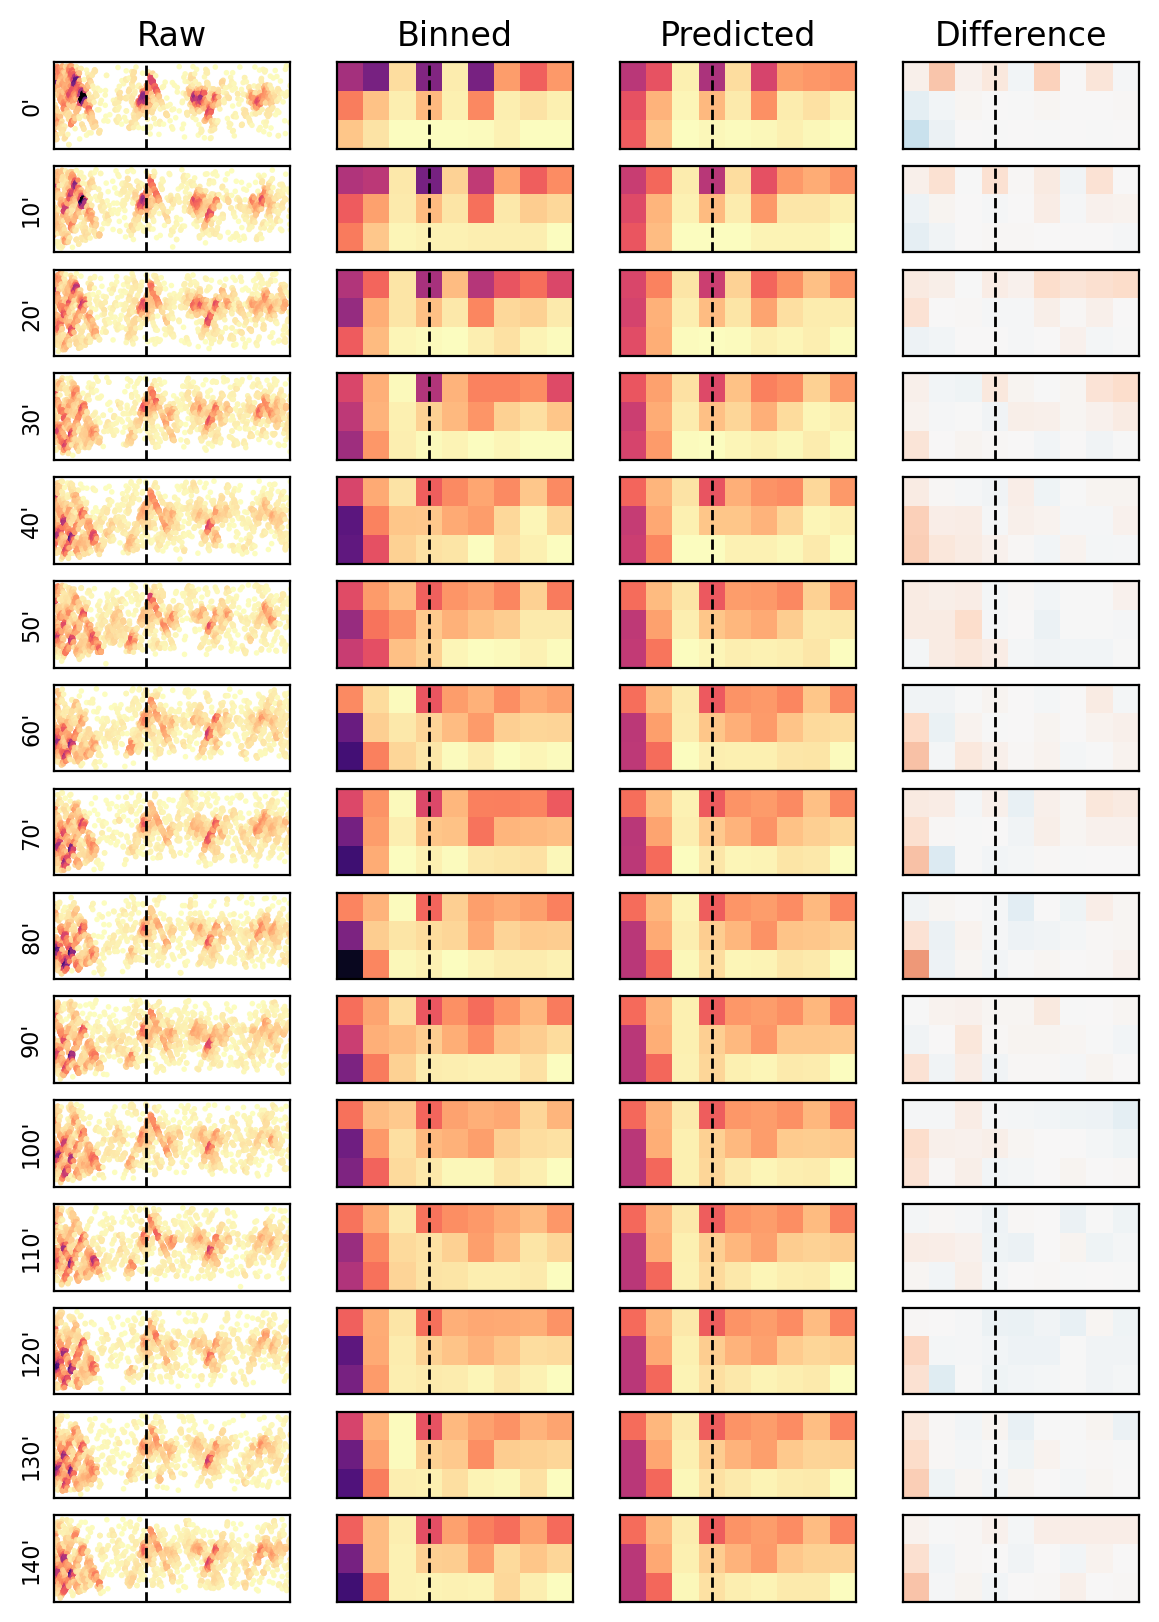

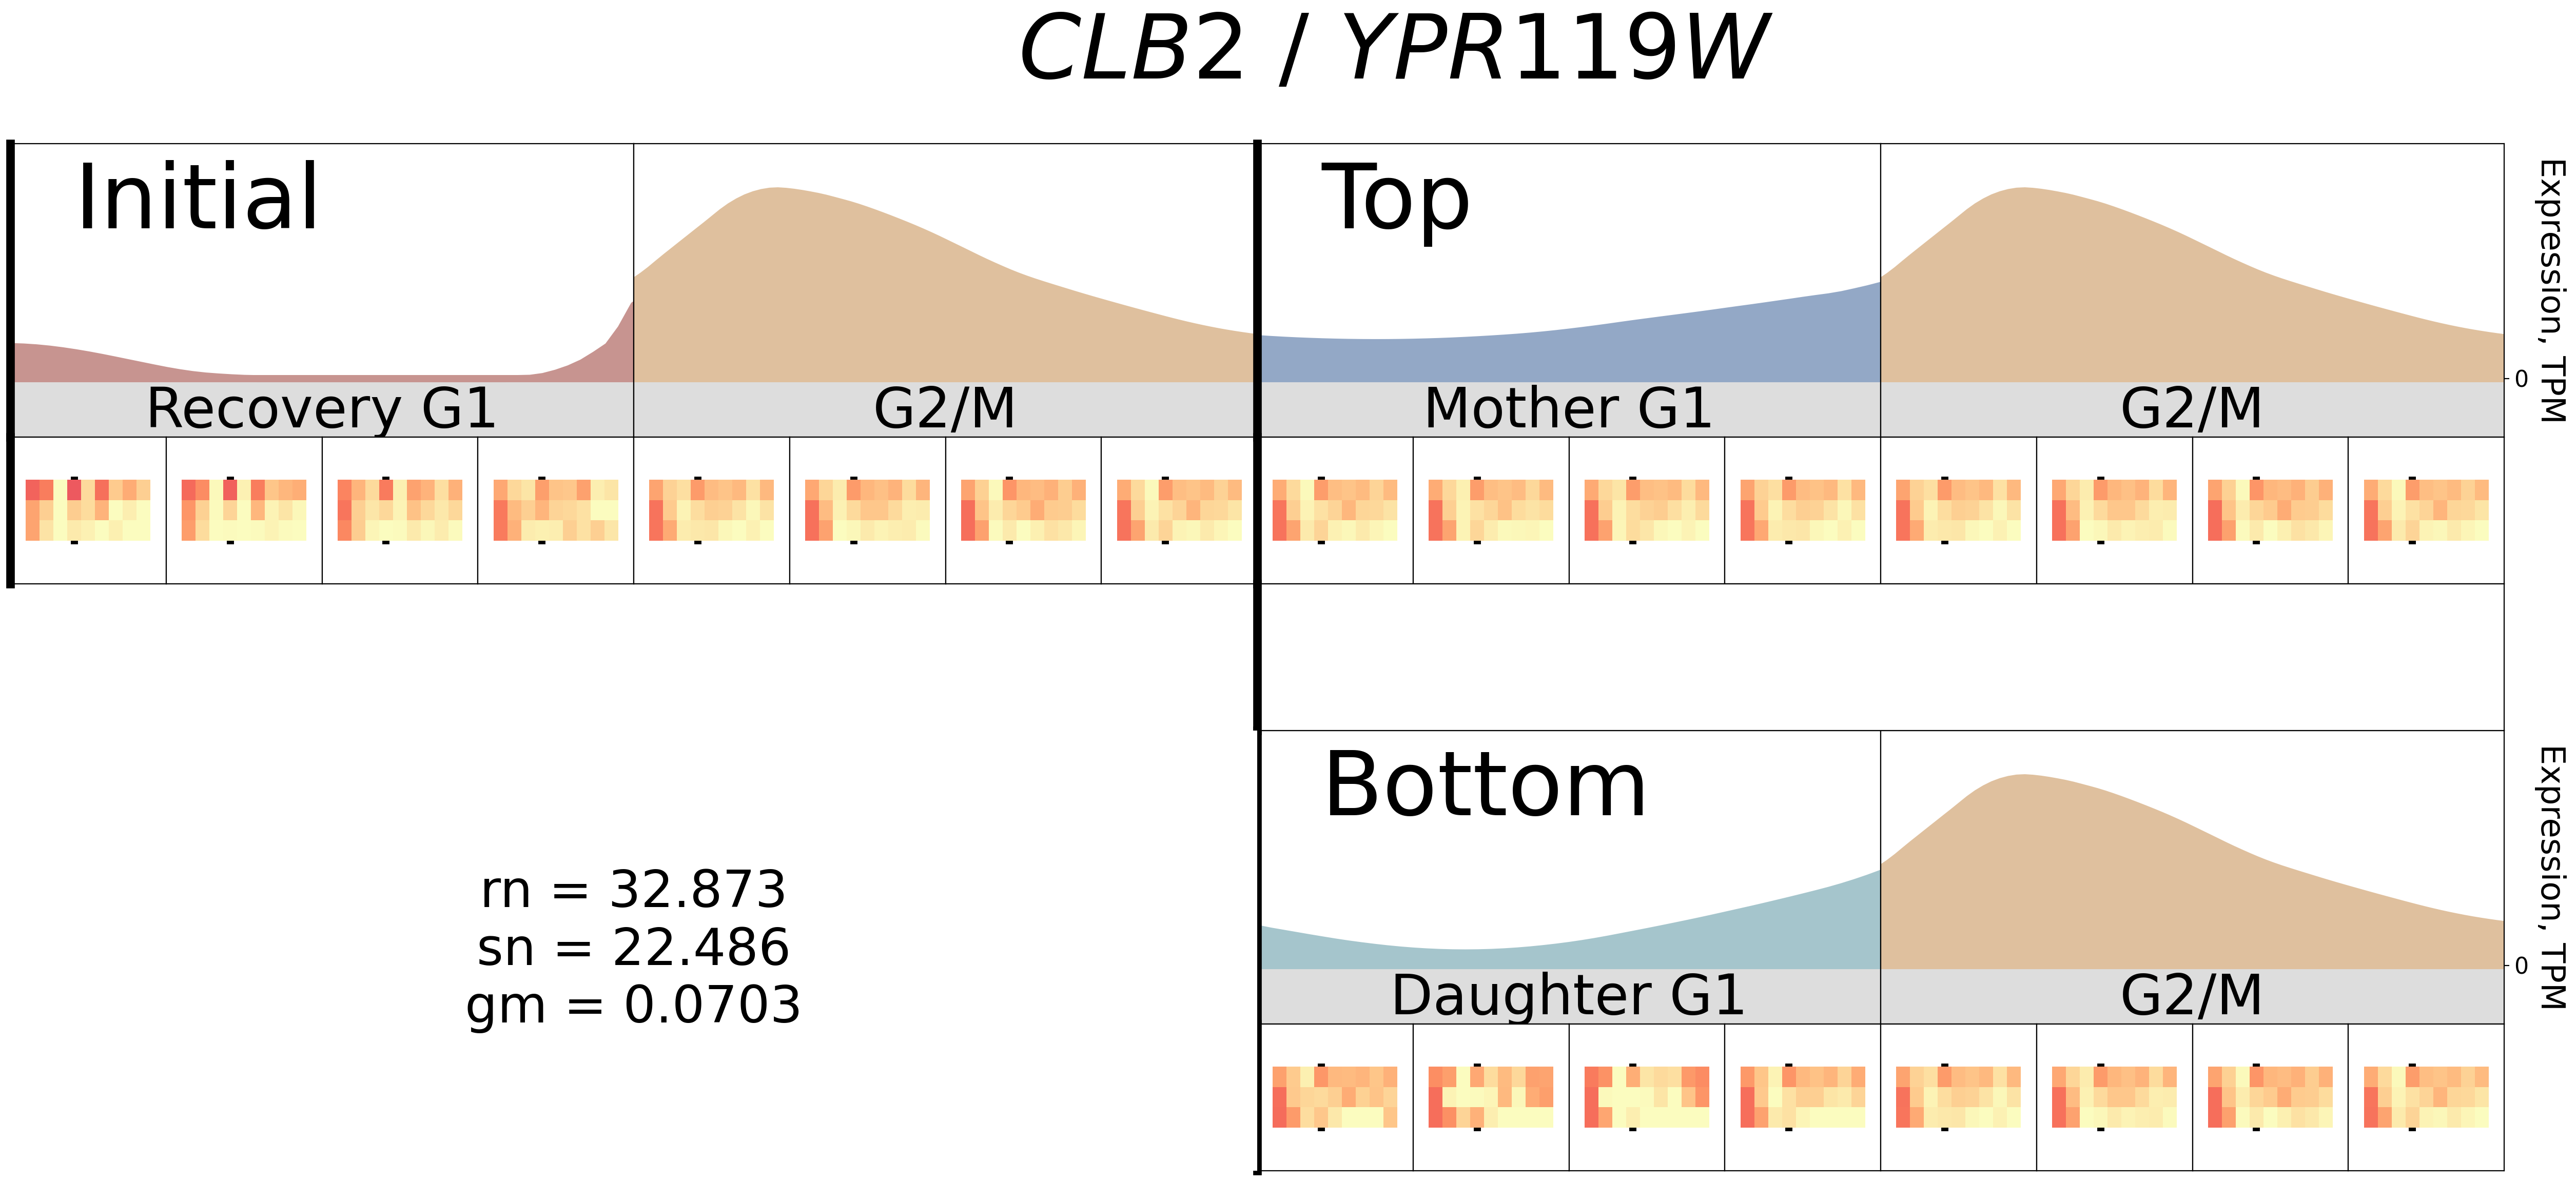

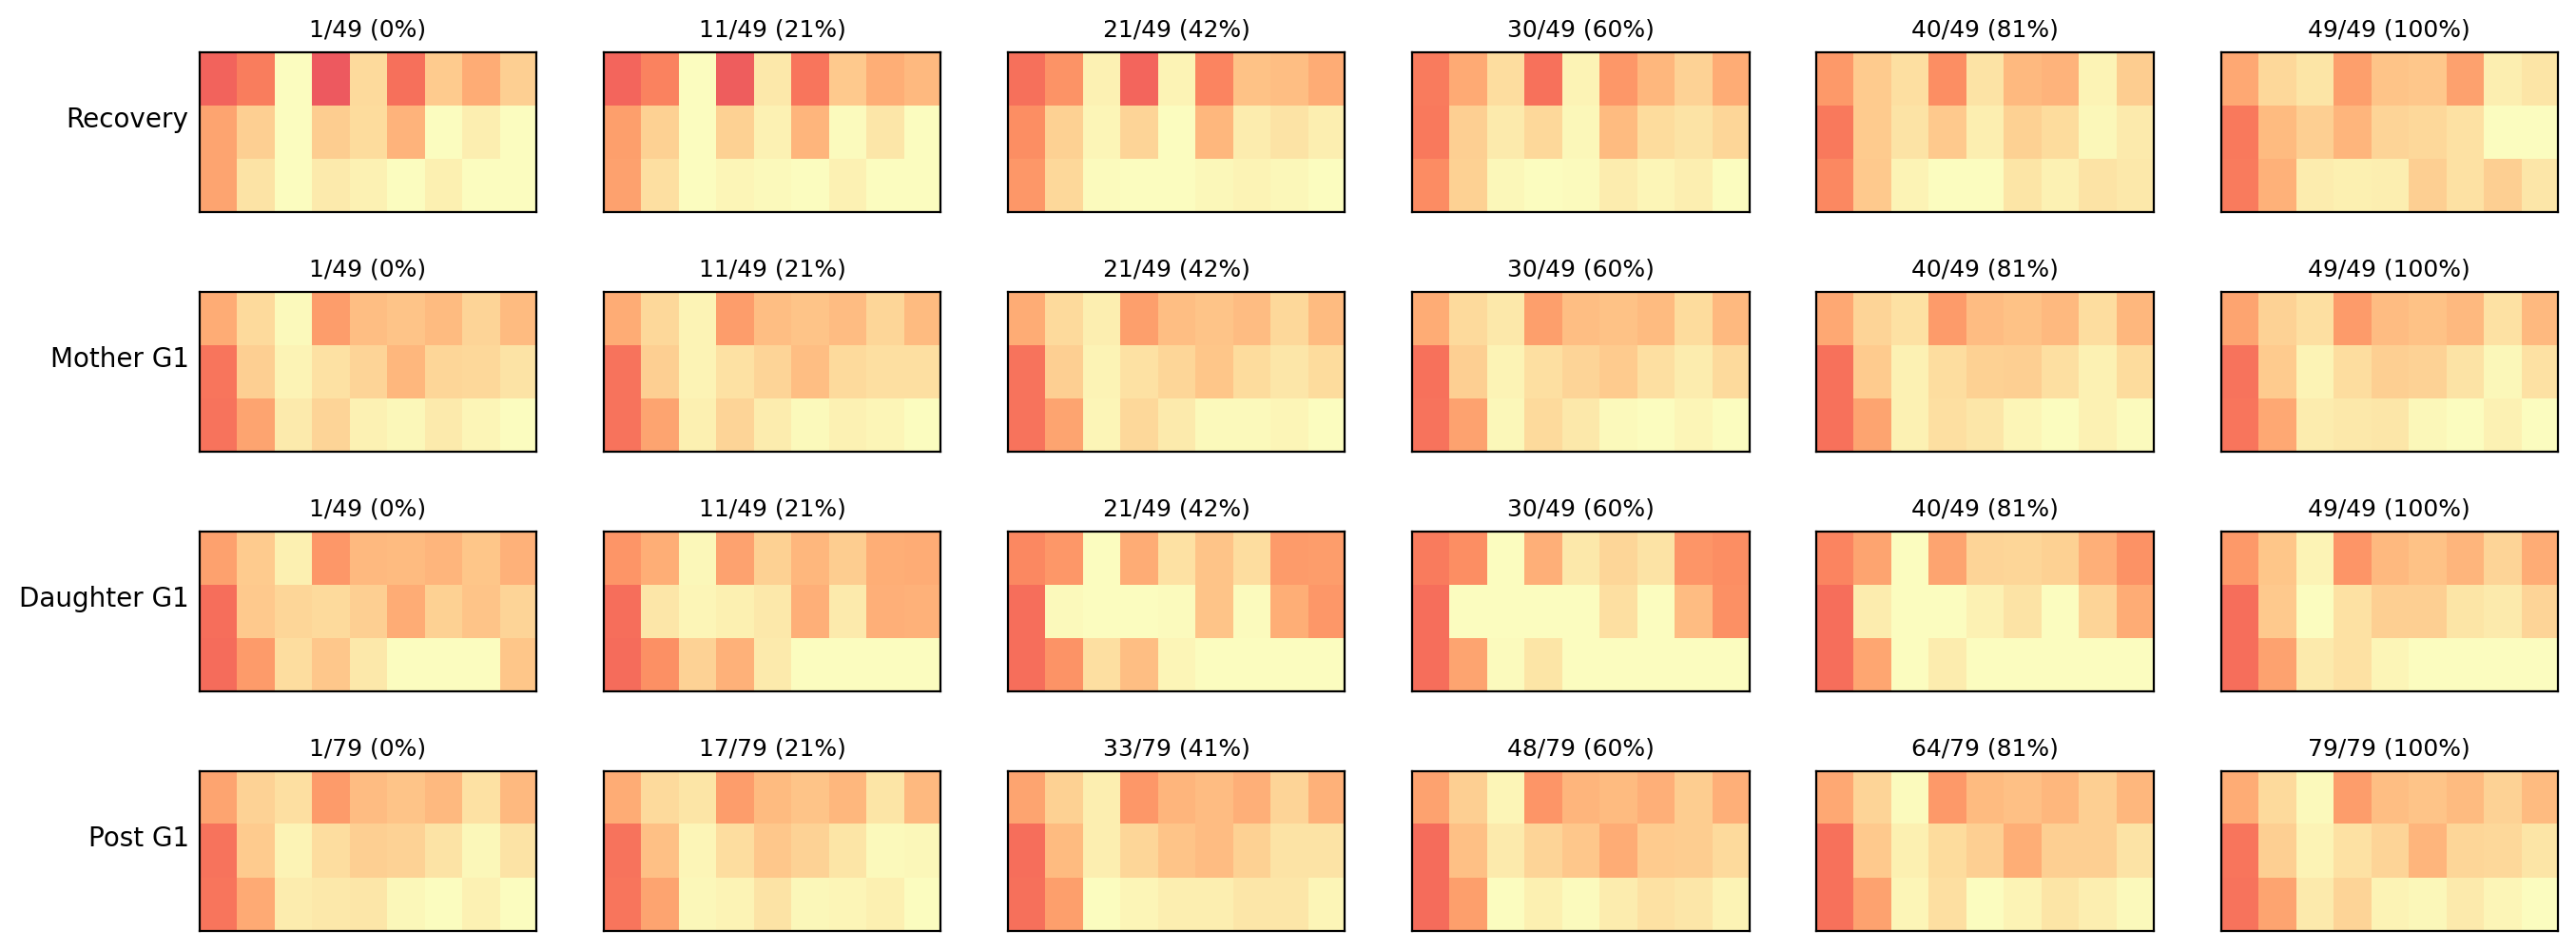

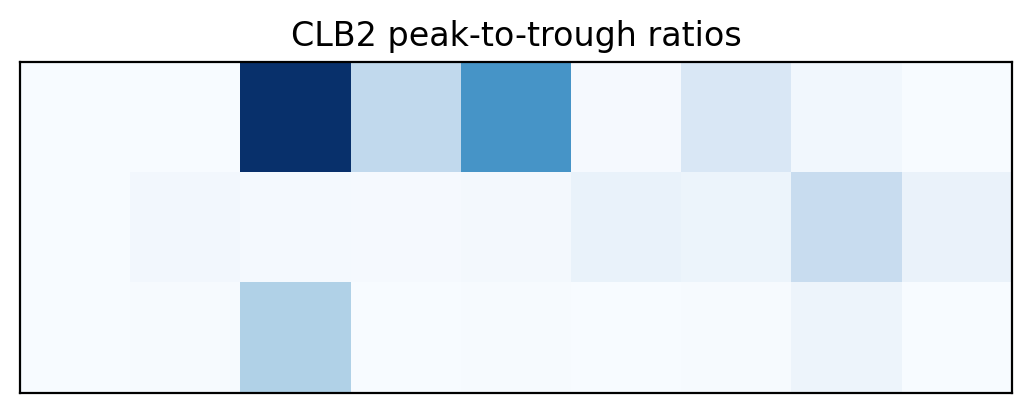

In [32]:
deconv_plotter.chromatin_gridder.create_bins_per_all_sample()
deconv_plotter.chromatin_gridder.plot_prediction_comparison(deconv_plotter.chrom_model)
deconv_plotter.plot_deconvolved_models()

fig, ax_rows = plt.subplots(4, 6, figsize=(16, 6))
plt.subplots_adjust(hspace=0.5)

deconv_plotter.chromatin_gridder.create_deconvolution_plots_abbreviated(
    deconv_plotter.chrom_model.f, deconv_plotter.chrom_model, ax_rows)

plt.figure()

plt.imshow(deconv_plotter.chrom_model.ptrs, cmap='Blues')
plt.xticks([])
plt.yticks([])
plt.title(f"{deconv_plotter.chrom_model.gene_name} peak-to-trough ratios")


Loading MNase reads...Done.
Now we have a data structure that we can try to deconvolve of shape: (15, 27)
The histogram shape around the TSS is: (3, 9)


Text(0.5, 1.0, 'RNR1 peak-to-trough ratios')

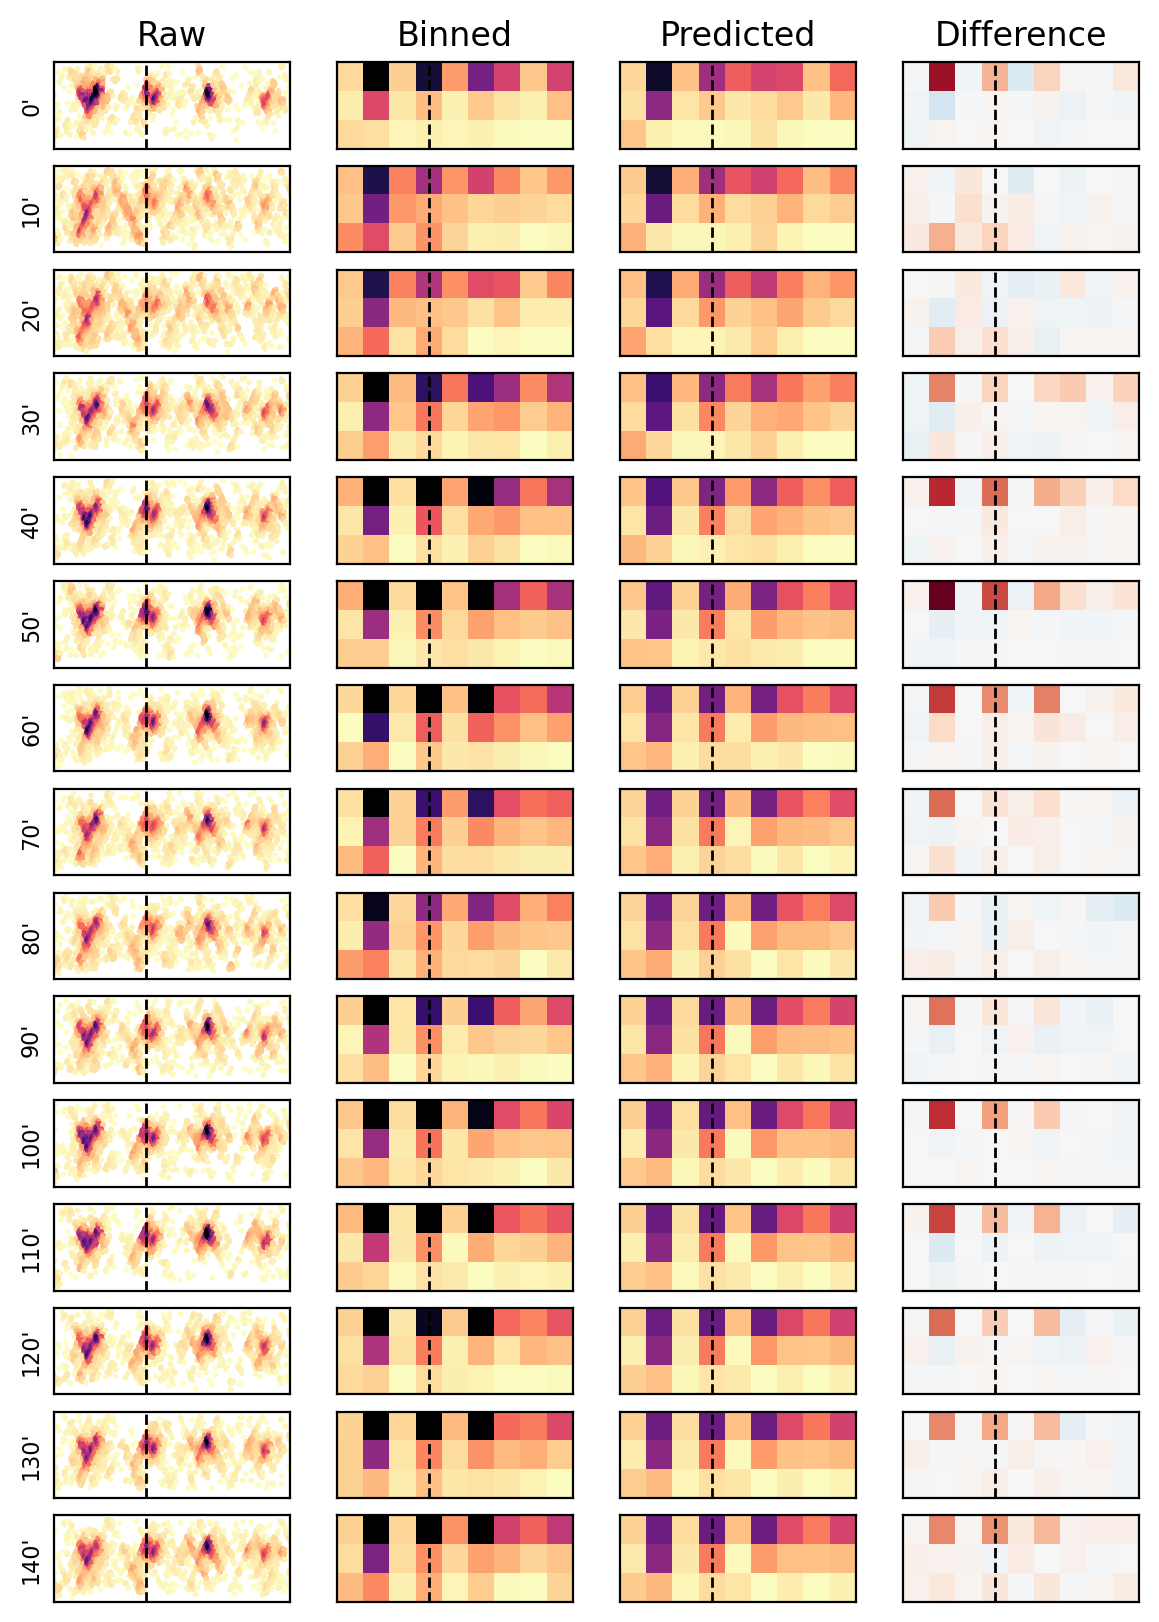

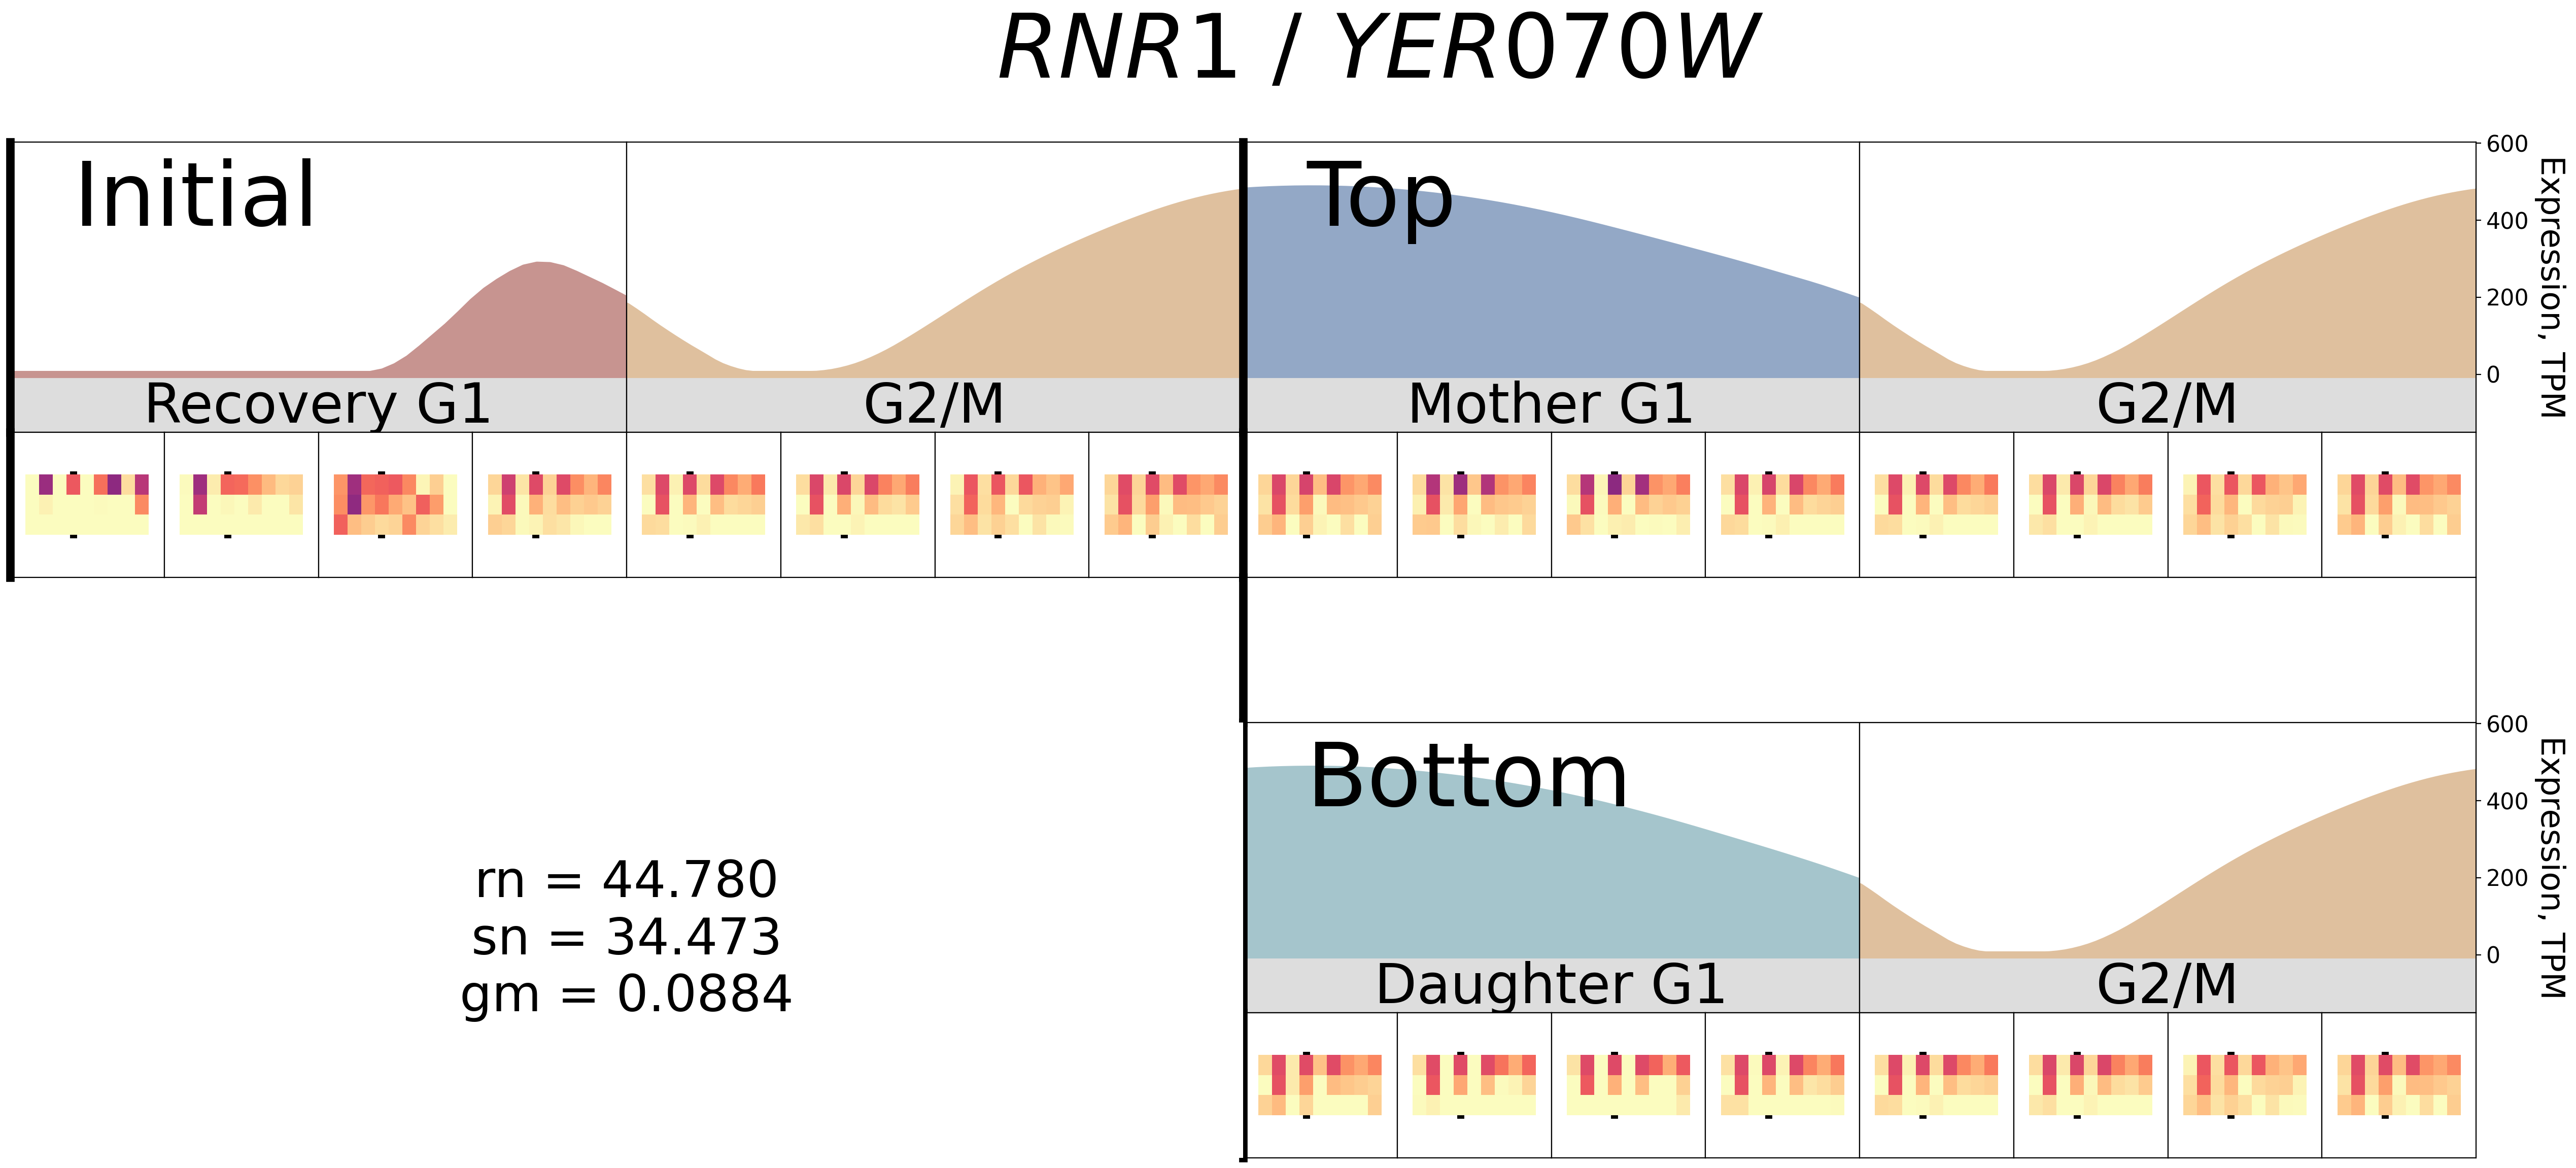

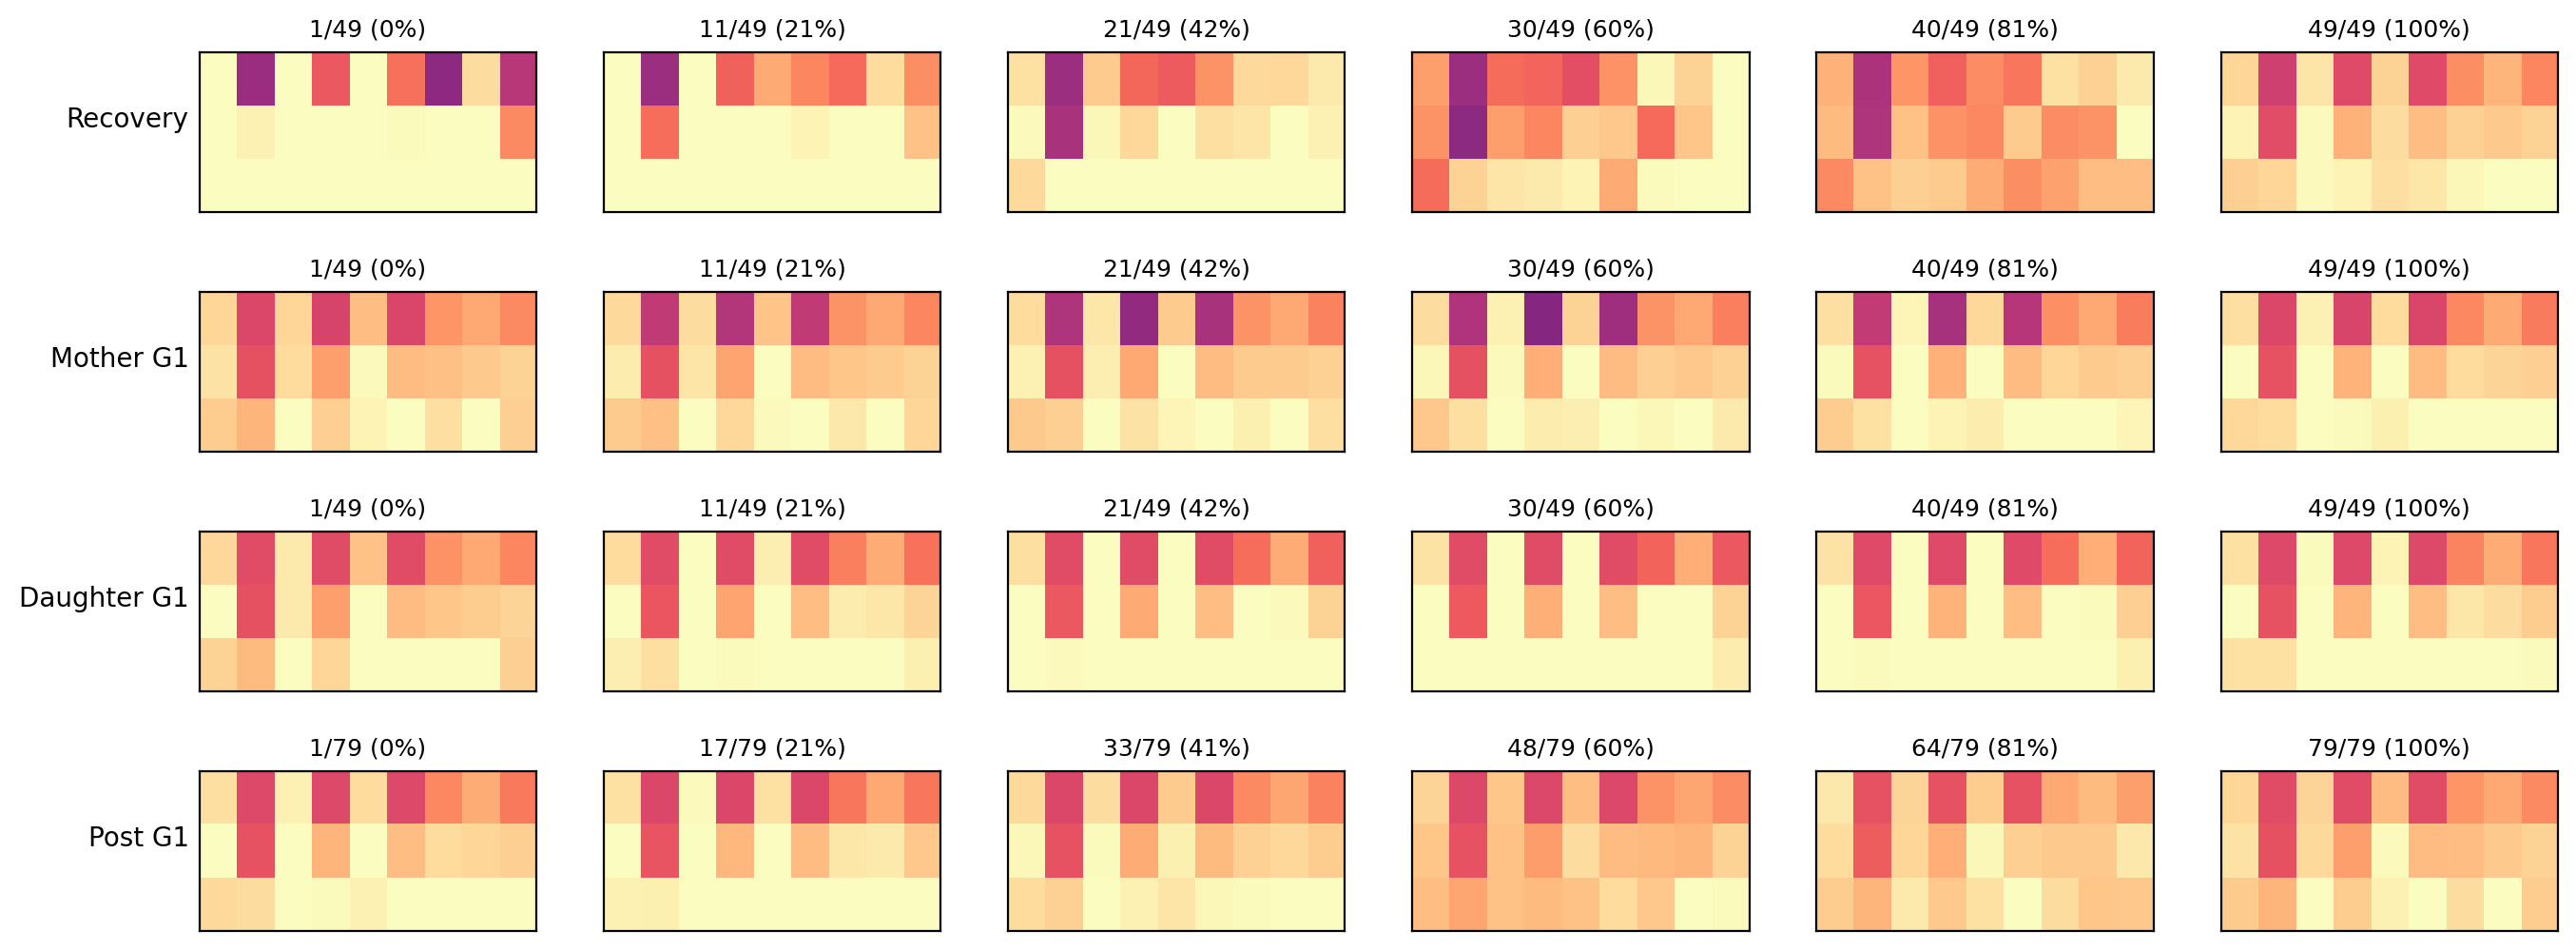

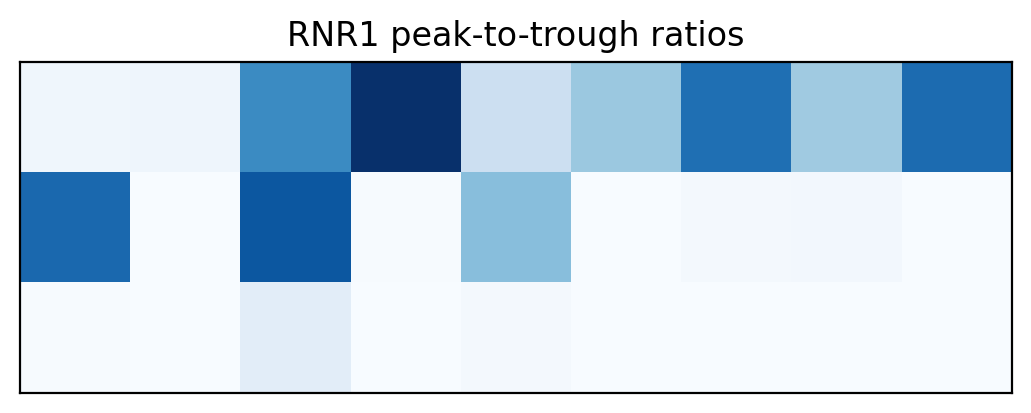

In [37]:
gene_name = 'RNR1'

deconv_plotter = load_deconvolution_models_from_disk(gene_name, chromatin_directory_path, 
                                    gene_expression_directory_path)

deconv_plotter.chromatin_gridder.create_bins_per_all_sample()
deconv_plotter.chromatin_gridder.plot_prediction_comparison(deconv_plotter.chrom_model)
deconv_plotter.plot_deconvolved_models()

fig, ax_rows = plt.subplots(4, 6, figsize=(16, 6))
plt.subplots_adjust(hspace=0.5)

deconv_plotter.chromatin_gridder.create_deconvolution_plots_abbreviated(
    deconv_plotter.chrom_model.f, deconv_plotter.chrom_model, ax_rows)

plt.figure()

plt.imshow(deconv_plotter.chrom_model.ptrs, cmap='Blues')
plt.xticks([])
plt.yticks([])
plt.title(f"{deconv_plotter.chrom_model.gene_name} peak-to-trough ratios")


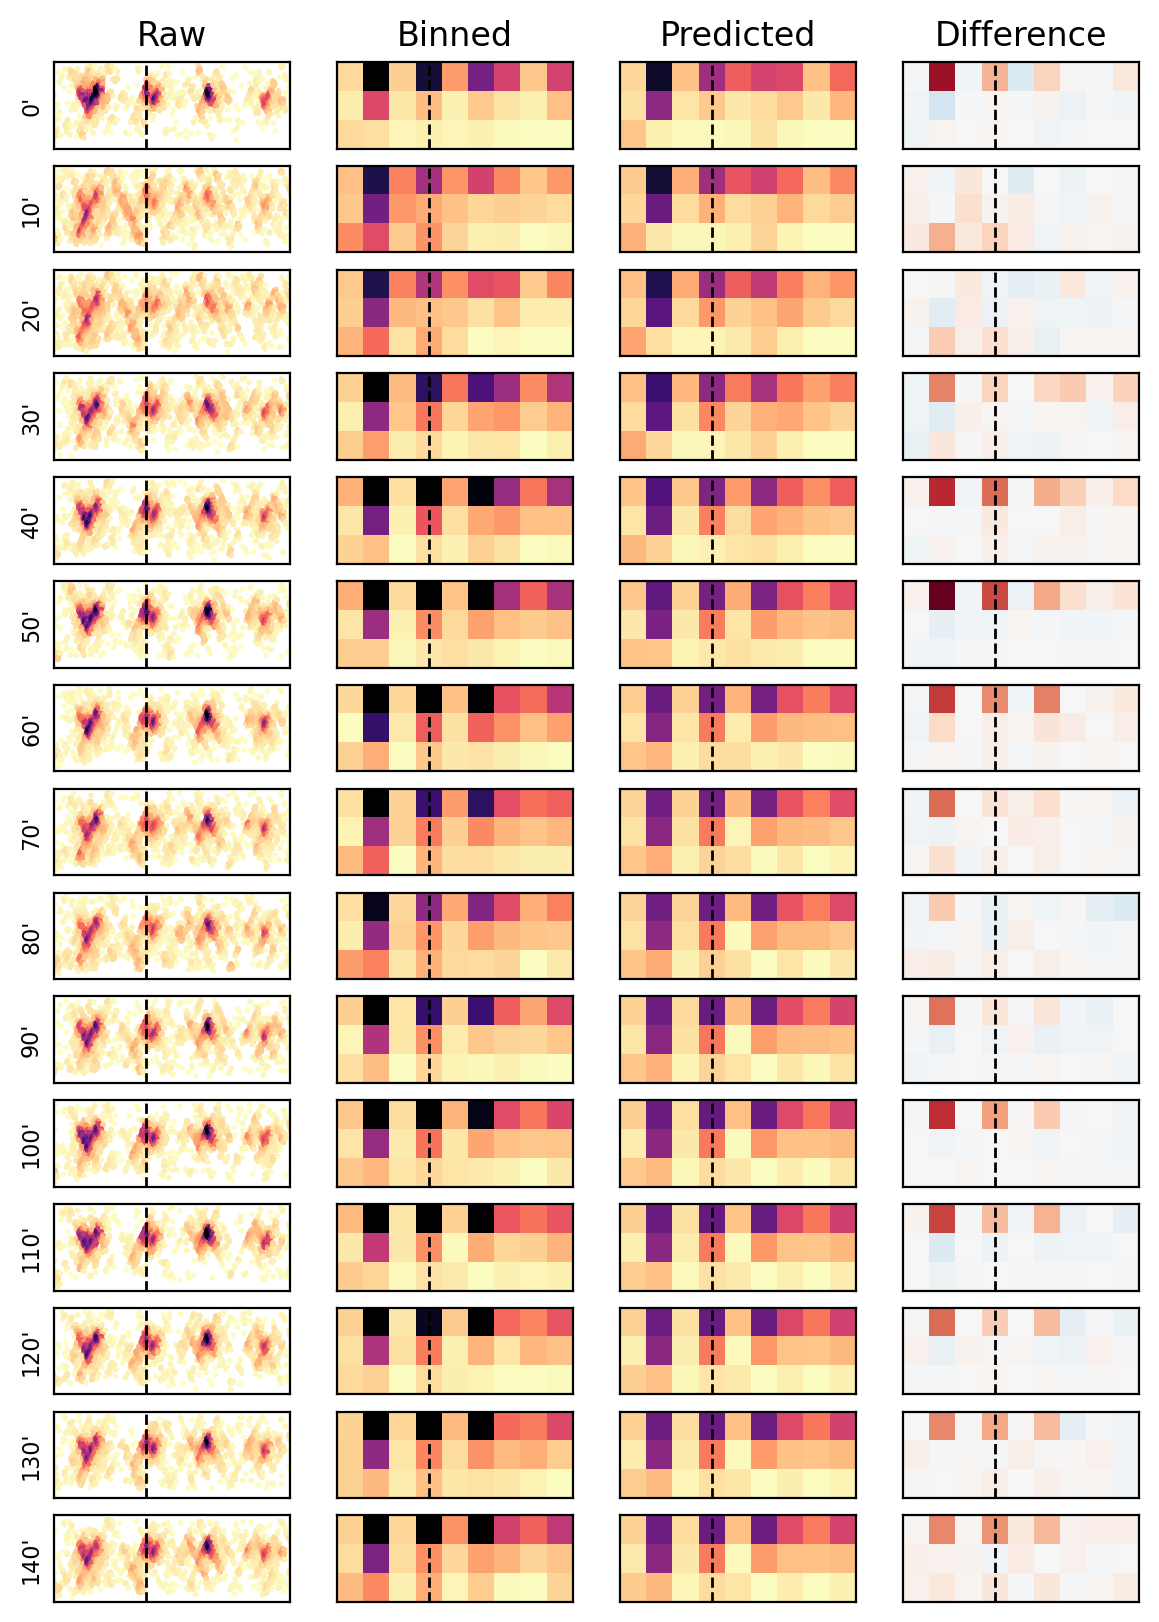

In [38]:
deconv_plotter.chromatin_gridder.plot_prediction_comparison(deconv_plotter.chrom_model)

In [40]:
deconv_plotter.ge_model.gamma

0.0073

In [58]:
deconv_plotter.ge_model.gamma = 0.0073
deconv_plotter.ge_model.deconvolve()

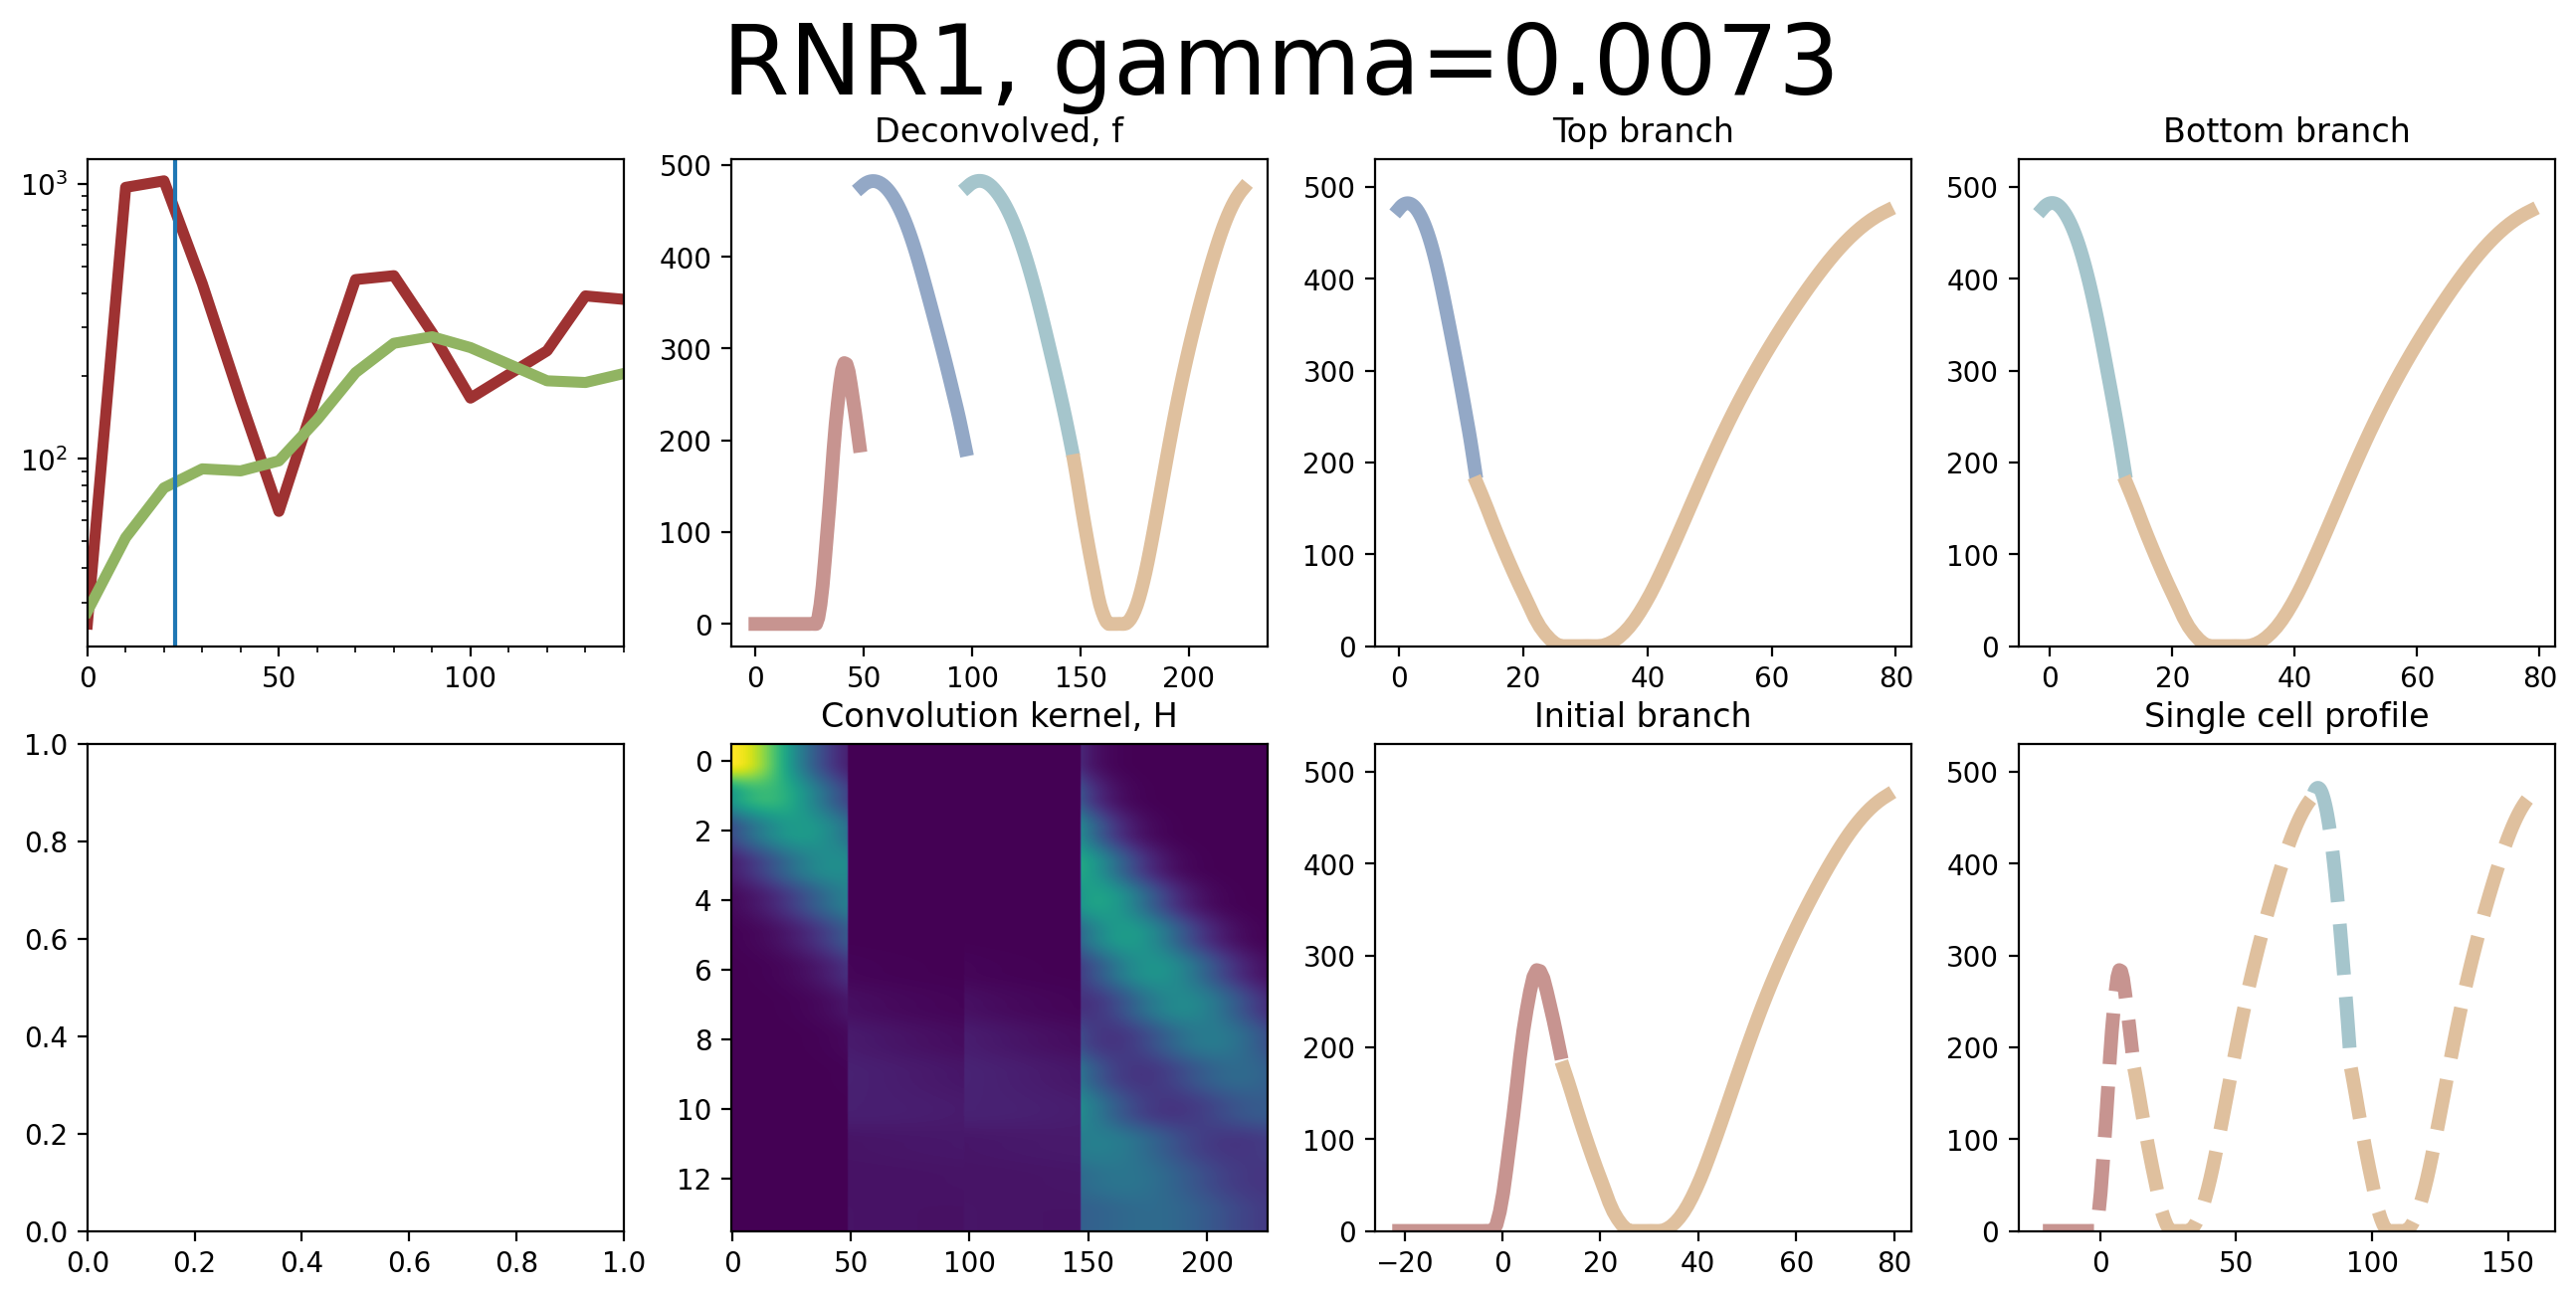

In [59]:
deconv_plotter.ge_model.plot_deconvolved_gene()